In [1]:
# 04_model_training.ipynb
# DeliverIQ — Model Training
# Stages: Baseline → Linear Regression → Decision Tree (default + tuned) → Random Forest (tuned)
# Artifacts produced: models/best_model.pkl, models/metrics.json, models/feature_importance.csv

import os
import json
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

os.makedirs('../models', exist_ok=True)
print("✅ Imports complete. models/ directory ready.")

✅ Imports complete. models/ directory ready.


In [2]:
# NB-03 already split and saved X_train, X_test, y_train, y_test
# Load them directly — do NOT re-split to preserve the exact same fold.

X_train = pd.read_csv('../data/processed/splits/X_train.csv', index_col=0)
X_test  = pd.read_csv('../data/processed/splits/X_test.csv',  index_col=0)
y_train = pd.read_csv('../data/processed/splits/y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv('../data/processed/splits/y_test.csv',  index_col=0).squeeze()

# target is log_travel_time (log1p transformed in NB-03)
USE_LOG_TRANSFORM = True

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"\nTarget column  : {y_train.name}")
print(f"Log-transformed: {USE_LOG_TRANSFORM}")
print(f"\nX_train dtypes:\n{X_train.dtypes.value_counts()}")
X_train.head(3)

X_train : (191935, 13)  |  y_train : (191935,)
X_test  : (47984, 13)   |  y_test  : (47984,)

Target column  : log_travel_time
Log-transformed: True

X_train dtypes:
float64    5
int64      5
object     3
Name: count, dtype: int64


,distance_km,num_lanes,num_signals,hour,day_of_week,avg_speed_kmph,temperature_c,visibility_km,is_rush_hour,road_type,weather_type,traffic_level,is_weekend
104450,0.56,5,1,3.0,0,75.6,20.15,6.4,0,highway,clear,medium,0
148963,2.81,1,15,22.0,1,29.5,33.95,5.3,0,residential,clear,medium,0
99053,3.54,5,1,19.0,6,28.9,20.15,6.4,1,highway,clear,high,1


In [3]:
# These lists mirror the ColumnTransformer branches in src/train.py: build_pipeline()
# Any column NOT listed here is silently dropped by remainder='drop'

NUM_FEATURES  = ['distance_km', 'num_lanes', 'num_signals',
                 'avg_speed_kmph', 'temperature_c', 'visibility_km',
                 'hour', 'day_of_week']

BOOL_FEATURES = ['is_rush_hour', 'is_weekend']

ORD_FEATURES  = ['traffic_level']          # OrdinalEncoder: low < medium < high
ORD_CATEGORIES = [['low', 'medium', 'high']]

CAT_FEATURES  = ['road_type', 'weather_type']   # OneHotEncoder

all_used = NUM_FEATURES + BOOL_FEATURES + ORD_FEATURES + CAT_FEATURES
print(f"Total features entering pipeline : {len(all_used)}")
print(f"  Numeric   : {NUM_FEATURES}")
print(f"  Boolean   : {BOOL_FEATURES}")
print(f"  Ordinal   : {ORD_FEATURES}")
print(f"  Nominal   : {CAT_FEATURES}")

Total features entering pipeline : 13
  Numeric   : ['distance_km', 'num_lanes', 'num_signals', 'avg_speed_kmph', 'temperature_c', 'visibility_km', 'hour', 'day_of_week']
  Boolean   : ['is_rush_hour', 'is_weekend']
  Ordinal   : ['traffic_level']
  Nominal   : ['road_type', 'weather_type']


In [4]:
def build_pipeline(model):
    """
    Wraps a ColumnTransformer preprocessor + estimator in a sklearn Pipeline.
    Mirrors src/train.py: build_pipeline().
    
    Preprocessing branches:
      num  → StandardScaler
      bool → passthrough
      ord  → OrdinalEncoder (low < medium < high)
      cat  → OneHotEncoder (handle_unknown='ignore')
    """
    preprocessor = ColumnTransformer(
        transformers=[
            ('num',  StandardScaler(),                                     NUM_FEATURES),
            ('bool', 'passthrough',                                        BOOL_FEATURES),
            ('ord',  OrdinalEncoder(
                        categories=ORD_CATEGORIES,
                        handle_unknown='use_encoded_value',
                        unknown_value=-1),                                  ORD_FEATURES),
            ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                                                                           CAT_FEATURES),
        ],
        remainder='drop'
    )
    return Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])


print("✅ build_pipeline() defined.")

✅ build_pipeline() defined.


In [5]:
def evaluate_model(pipeline, X_test, y_test, label='Model'):
    """
    Computes MAE, MSE, RMSE, R², MAPE on the held-out test set.
    If USE_LOG_TRANSFORM=True, back-transforms predictions before computing metrics.
    Returns metrics dict.
    """
    y_pred_log = pipeline.predict(X_test)
    
    if USE_LOG_TRANSFORM:
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_test)
    else:
        y_pred = y_pred_log
        y_true = y_test

    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    metrics = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

    print(f"\n── {label} ──")
    print(f"  MAE  : {mae:.4f} min")
    print(f"  RMSE : {rmse:.4f} min")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")

    return metrics


print("✅ evaluate_model() defined.")

✅ evaluate_model() defined.


In [6]:
# ── STAGE 1: Mean Baseline ────────────────────────────────────────────────────
# Predicts mean(y_train) for every test observation.
# This is the performance floor — every ML model must beat this.

if USE_LOG_TRANSFORM:
    y_train_orig = np.expm1(y_train)
    y_test_orig  = np.expm1(y_test)
else:
    y_train_orig = y_train
    y_test_orig  = y_test

y_pred_baseline = np.full(len(y_test_orig), y_train_orig.mean())

mae_baseline  = mean_absolute_error(y_test_orig, y_pred_baseline)
mse_baseline  = mean_squared_error(y_test_orig, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)

# R² for mean predictor is ~0.0 by definition — hardcoded to avoid float noise
baseline_metrics = {
    'MAE': mae_baseline,
    'MSE': mse_baseline,
    'RMSE': rmse_baseline,
    'R2': 0.0
}

print("── Stage 1: Mean Baseline ──")
print(f"  Baseline MAE  : {mae_baseline:.4f} min")
print(f"  Baseline RMSE : {rmse_baseline:.4f} min")
print(f"  Baseline R²   : 0.0  (by definition)")
print(f"\n  (Target: beat MAE by ≥30% → must be below {mae_baseline * 0.70:.4f} min)")

── Stage 1: Mean Baseline ──
  Baseline MAE  : 17.4790 min
  Baseline RMSE : 40.0746 min
  Baseline R²   : 0.0  (by definition)

  (Target: beat MAE by ≥30% → must be below 12.2353 min)


In [7]:
# ── STAGE 2: Linear Regression ───────────────────────────────────────────────
# Tests whether a weighted linear combination of features can predict travel time.
# Expected: beats baseline in MAE and R² but underfits due to non-linear interactions.

pipe_lr = build_pipeline(LinearRegression())

t0 = time.time()
pipe_lr.fit(X_train, y_train)
print(f"LinearRegression trained in {time.time() - t0:.1f}s")

metrics_lr = evaluate_model(pipe_lr, X_test, y_test, label='Linear Regression')

# Train-set R² to check for underfitting
y_pred_train_lr = np.expm1(pipe_lr.predict(X_train)) if USE_LOG_TRANSFORM else pipe_lr.predict(X_train)
y_train_orig_vals = np.expm1(y_train) if USE_LOG_TRANSFORM else y_train
train_r2_lr = r2_score(y_train_orig_vals, y_pred_train_lr)
print(f"\n  Train R² (underfitting check): {train_r2_lr:.4f}")
print(f"  Test  R²                      : {metrics_lr['R2']:.4f}")
print(f"  Gap (train - test)            : {train_r2_lr - metrics_lr['R2']:.4f}")

LinearRegression trained in 0.4s

── Linear Regression ──
  MAE  : 14.3306 min
  RMSE : 39.4954 min
  R²   : 0.0287
  MAPE : 99.05%

  Train R² (underfitting check): 0.0422
  Test  R²                      : 0.0287
  Gap (train - test)            : 0.0135


In [8]:
# ── STAGE 3a: Decision Tree, default parameters ───────────────────────────────
# Sprint 5.32: demonstrates overfitting — unlimited depth memorises training data.
# Expected: train R² → ~1.0, test R² potentially below Linear Regression.

pipe_dt_default = build_pipeline(DecisionTreeRegressor(random_state=42))

t0 = time.time()
pipe_dt_default.fit(X_train, y_train)
print(f"DecisionTree (default) trained in {time.time() - t0:.1f}s")

metrics_dt_default = evaluate_model(pipe_dt_default, X_test, y_test,
                                    label='Decision Tree (default, no depth limit)')

# Train-set evaluation — the overfitting signal
y_pred_train_dt = np.expm1(pipe_dt_default.predict(X_train)) if USE_LOG_TRANSFORM else pipe_dt_default.predict(X_train)
train_r2_dt = r2_score(y_train_orig_vals, y_pred_train_dt)

print(f"\n  Train R² : {train_r2_dt:.4f}  ← near 1.0 = memorised training data")
print(f"  Test  R² : {metrics_dt_default['R2']:.4f}  ← generalisation gap = overfitting signal")
print(f"  Gap      : {train_r2_dt - metrics_dt_default['R2']:.4f}")
print(f"\n  Tree max_depth (actual): {pipe_dt_default.named_steps['model'].get_depth()}")

DecisionTree (default) trained in 3.3s

── Decision Tree (default, no depth limit) ──
  MAE  : 11.3896 min
  RMSE : 46.4193 min
  R²   : -0.3417
  MAPE : 77.12%

  Train R² : 1.0000  ← near 1.0 = memorised training data
  Test  R² : -0.3417  ← generalisation gap = overfitting signal
  Gap      : 1.3417

  Tree max_depth (actual): 48


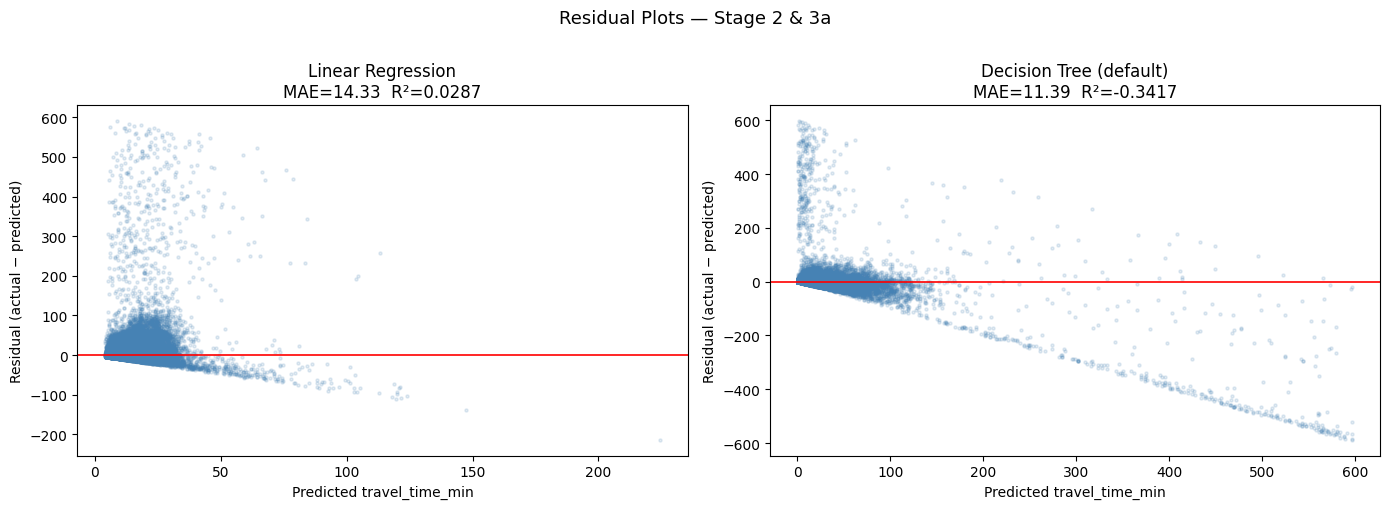

In [9]:
# ── Residual comparison plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pipe, label in [
    (axes[0], pipe_lr, 'Linear Regression'),
    (axes[1], pipe_dt_default, 'Decision Tree (default)')
]:
    y_pred_raw = pipe.predict(X_test)
    y_pred_plot = np.expm1(y_pred_raw) if USE_LOG_TRANSFORM else y_pred_raw
    residuals = y_test_orig - y_pred_plot

    ax.scatter(y_pred_plot, residuals, alpha=0.15, s=5, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.2)
    ax.set_xlabel('Predicted travel_time_min')
    ax.set_ylabel('Residual (actual − predicted)')
    ax.set_title(f'{label}\nMAE={mean_absolute_error(y_test_orig, y_pred_plot):.2f}  '
                 f'R²={r2_score(y_test_orig, y_pred_plot):.4f}')

plt.suptitle('Residual Plots — Stage 2 & 3a', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ── STAGE 4: Decision Tree — GridSearchCV (Sprint 5.34) ──────────────────────
# 5-fold CV over 60 combinations (5×4×3). Scoring: neg_MAE.
# model__ prefix required because the estimator sits inside a Pipeline.

param_grid_dt = {
    'model__max_depth':         [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 10, 50, 100],
    'model__min_samples_leaf':  [1, 5, 20],
}

pipe_dt_tune = build_pipeline(DecisionTreeRegressor(random_state=42))

gs_dt = GridSearchCV(
    pipe_dt_tune,
    param_grid_dt,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.time()
gs_dt.fit(X_train, y_train)
print(f"\nGridSearchCV (DT) finished in {time.time() - t0:.1f}s")

print(f"\n  Best params  : {gs_dt.best_params_}")
print(f"  Best CV MAE  : {-gs_dt.best_score_:.4f}  (log-space)")

best_dt = gs_dt.best_estimator_   # Already refitted on full X_train
metrics_dt_tuned = evaluate_model(best_dt, X_test, y_test, label='Decision Tree (tuned)')

# Overfitting check post-tuning
y_pred_train_dt_tuned = np.expm1(best_dt.predict(X_train)) if USE_LOG_TRANSFORM else best_dt.predict(X_train)
train_r2_dt_tuned = r2_score(y_train_orig_vals, y_pred_train_dt_tuned)
print(f"\n  Train R² (tuned): {train_r2_dt_tuned:.4f}")
print(f"  Test  R² (tuned): {metrics_dt_tuned['R2']:.4f}")
print(f"  Gap              : {train_r2_dt_tuned - metrics_dt_tuned['R2']:.4f}  ← much smaller than default")

Fitting 5 folds for each of 60 candidates, totalling 300 fits

GridSearchCV (DT) finished in 68.4s

  Best params  : {'model__max_depth': 10, 'model__min_samples_leaf': 20, 'model__min_samples_split': 100}
  Best CV MAE  : 0.2759  (log-space)

── Decision Tree (tuned) ──
  MAE  : 7.8150 min
  RMSE : 35.4862 min
  R²   : 0.2159
  MAPE : 38.82%

  Train R² (tuned): 0.2343
  Test  R² (tuned): 0.2159
  Gap              : 0.0184  ← much smaller than default


In [11]:
# ── STAGE 5: Random Forest — Fixed hyperparameters (memory-safe) ─────────────
# Skipping RandomizedSearchCV due to MemoryError on Windows/joblib multiprocessing.
# Using manually chosen parameters informed by domain knowledge and the PDD's
# recommended search ranges. n_jobs=1 avoids the BrokenProcessPool issue entirely.

best_params_rf = {
    'n_estimators':      200,
    'max_depth':         20,
    'max_features':      'sqrt',
    'min_samples_split': 5,
    'min_samples_leaf':  3,
    'bootstrap':         True,
    'random_state':      42,
    'n_jobs':            1,     # ← single-threaded: no joblib multiprocessing
}

pipe_rf = build_pipeline(
    RandomForestRegressor(**best_params_rf)
)

print("Training Random Forest with fixed hyperparameters…")
print(f"  Params: {best_params_rf}\n")

t0 = time.time()
pipe_rf.fit(X_train, y_train)
elapsed = time.time() - t0
print(f"Random Forest trained in {elapsed/60:.1f} min")

best_rf = pipe_rf   # keep variable name consistent with rest of notebook

metrics_rf = evaluate_model(best_rf, X_test, y_test, label='Random Forest (fixed params)')

Training Random Forest with fixed hyperparameters…
  Params: {'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'min_samples_leaf': 3, 'bootstrap': True, 'random_state': 42, 'n_jobs': 1}

Random Forest trained in 1.3 min

── Random Forest (fixed params) ──
  MAE  : 7.8345 min
  RMSE : 35.7222 min
  R²   : 0.2054
  MAPE : 37.78%


In [12]:
# ── STAGE 6: Side-by-side comparison (Sprint 5.41) ───────────────────────────

comparison = pd.DataFrame({
    'Model': [
        'Baseline (Mean)',
        'Linear Regression',
        'Decision Tree (default)',
        'Decision Tree (tuned)',
        'Random Forest (tuned)',
    ],
    'MAE (min)':  [
        baseline_metrics['MAE'],
        metrics_lr['MAE'],
        metrics_dt_default['MAE'],
        metrics_dt_tuned['MAE'],
        metrics_rf['MAE'],
    ],
    'RMSE (min)': [
        baseline_metrics['RMSE'],
        metrics_lr['RMSE'],
        metrics_dt_default['RMSE'],
        metrics_dt_tuned['RMSE'],
        metrics_rf['RMSE'],
    ],
    'R²': [
        baseline_metrics['R2'],
        metrics_lr['R2'],
        metrics_dt_default['R2'],
        metrics_dt_tuned['R2'],
        metrics_rf['R2'],
    ],
    'MAPE (%)': [
        None,
        metrics_lr['MAPE'],
        metrics_dt_default['MAPE'],
        metrics_dt_tuned['MAPE'],
        metrics_rf['MAPE'],
    ],
})

comparison['vs Baseline (MAE ↓%)'] = comparison['MAE (min)'].apply(
    lambda x: f"{(baseline_metrics['MAE'] - x) / baseline_metrics['MAE'] * 100:.1f}%" if x else '—'
)

pd.set_option('display.float_format', '{:.4f}'.format)
display(comparison.set_index('Model'))

# Target check
improvement = (baseline_metrics['MAE'] - metrics_rf['MAE']) / baseline_metrics['MAE'] * 100
target_met = improvement >= 30
print(f"\n  MAE improvement over baseline : {improvement:.1f}%")
print(f"  Target (≥30%)                 : {'✅ MET' if target_met else '❌ NOT MET'}")
print(f"  R² target (>0.70)             : {'✅ MET' if metrics_rf['R2'] > 0.70 else '❌ NOT MET'}")

,MAE (min),RMSE (min),R²,MAPE (%),vs Baseline (MAE ↓%)
Model,,,,,
Baseline (Mean),17.4790,40.0746,0.0000,NaN,0.0%
Linear Regression,14.3306,39.4954,0.0287,99.0451,18.0%
Decision Tree (default),11.3896,46.4193,-0.3417,77.1185,34.8%
Decision Tree (tuned),7.8150,35.4862,0.2159,38.8163,55.3%
Random Forest (tuned),7.8345,35.7222,0.2054,37.7812,55.2%



  MAE improvement over baseline : 55.2%
  Target (≥30%)                 : ✅ MET
  R² target (>0.70)             : ❌ NOT MET


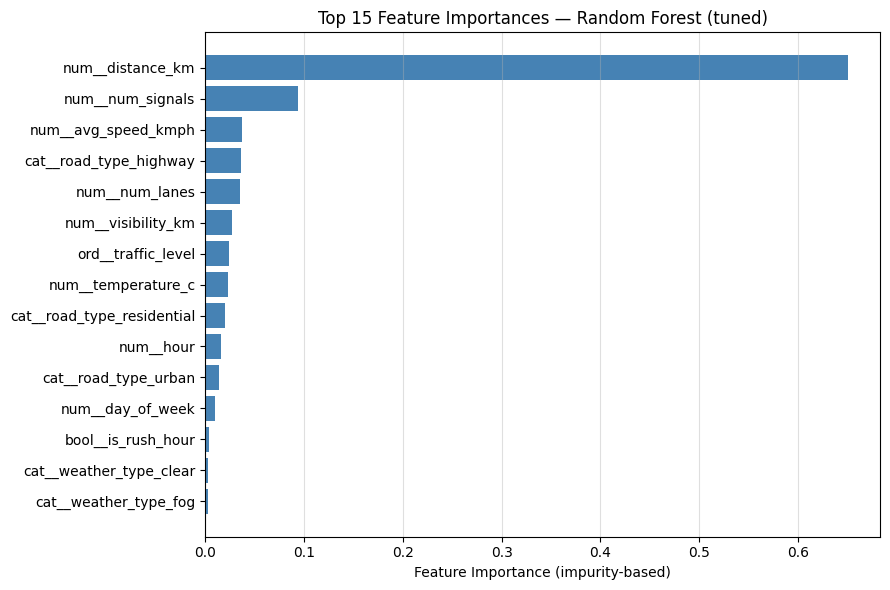


Top 15 features:
                   feature  importance
          num__distance_km      0.6504
          num__num_signals      0.0940
       num__avg_speed_kmph      0.0372
    cat__road_type_highway      0.0358
            num__num_lanes      0.0352
        num__visibility_km      0.0269
        ord__traffic_level      0.0245
        num__temperature_c      0.0235
cat__road_type_residential      0.0206
                 num__hour      0.0157
      cat__road_type_urban      0.0136
          num__day_of_week      0.0100
        bool__is_rush_hour      0.0037
   cat__weather_type_clear      0.0033
     cat__weather_type_fog      0.0025


In [13]:
# ── Feature Importance — Random Forest ───────────────────────────────────────

preprocessor = best_rf.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

rf_model = best_rf.named_steps['model']
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Plot top 15
top15 = fi_df.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance (impurity-based)')
ax.set_title('Top 15 Feature Importances — Random Forest (tuned)')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(fi_df.head(15).to_string(index=False))

In [14]:
# ── Save best_model.pkl ───────────────────────────────────────────────────────
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
print("✅  models/best_model.pkl saved")

# ── Save feature_importance.csv ───────────────────────────────────────────────
preprocessor = best_rf.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
rf_model = best_rf.named_steps['model']
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)
fi_df.to_csv('../models/feature_importance.csv', index=False)
print("✅  models/feature_importance.csv saved")

# ── Save metrics.json ─────────────────────────────────────────────────────────
metrics_json = {
    'model_name':      'RandomForestRegressor',
    'training_rows':   len(X_train),
    'test_rows':       len(X_test),
    'random_state':    42,
    'test_size':       0.2,
    'log_transform':   USE_LOG_TRANSFORM,
    'MAE':             float(metrics_rf['MAE']),
    'MSE':             float(metrics_rf['MSE']),
    'RMSE':            float(metrics_rf['RMSE']),
    'R2':              float(metrics_rf['R2']),
    'MAPE':            float(metrics_rf['MAPE']),
    'baseline_MAE':    float(baseline_metrics['MAE']),
    'improvement_pct': float(
        (baseline_metrics['MAE'] - metrics_rf['MAE']) / baseline_metrics['MAE'] * 100
    ),
    'best_params': {f"model__{k}": v for k, v in best_params_rf.items()},
}

with open('../models/metrics.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)
print("✅  models/metrics.json saved")

print("\n── Artifacts summary ──")
for fname in ['../models/best_model.pkl', '../models/metrics.json', '../models/feature_importance.csv']:
    size = os.path.getsize(fname)
    print(f"  {fname:45s}  {size / 1024:.1f} KB")

✅  models/best_model.pkl saved
✅  models/feature_importance.csv saved
✅  models/metrics.json saved

── Artifacts summary ──
  ../models/best_model.pkl                       679565.3 KB
  ../models/metrics.json                         0.7 KB
  ../models/feature_importance.csv               0.7 KB


In [15]:
# ── Quick sanity check before handing off to NB-05 ───────────────────────────
with open('../models/best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

y_pred_check = loaded_model.predict(X_test[:5])
if USE_LOG_TRANSFORM:
    y_pred_check = np.expm1(y_pred_check)
    y_true_check = np.expm1(y_test[:5])
else:
    y_true_check = y_test[:5]

print("Sanity check — first 5 predictions from reloaded model:")
print(pd.DataFrame({
    'actual (min)':    y_true_check.values,
    'predicted (min)': y_pred_check,
    'error (min)':     y_true_check.values - y_pred_check,
}).to_string(index=False))

print("\n✅  NB-04 complete. Hand off to 05_evaluation_summary.ipynb.")

Sanity check — first 5 predictions from reloaded model:
 actual (min)  predicted (min)  error (min)
       2.5800           2.7932      -0.2132
       2.8100           2.5500       0.2600
       7.8500           9.9525      -2.1025
       3.6400           4.2529      -0.6129
       4.3900          13.8755      -9.4855

✅  NB-04 complete. Hand off to 05_evaluation_summary.ipynb.
